# GFP DMS — bright/dim classifier architecture sweep

Visualizes the multi-GPU **bright vs dim** classifier sweep in `sweep_classify_parallel.py`, which
predicts the `brightnessClass` label from ESM-2 650M per-residue embeddings on a stratified **20,000-row
subsample spanning all four GFP scaffolds** (avGFP + amacGFP + cgreGFP + ppluGFP, 5,000 rows each; built
by `build_subsample.py`).

Grid: CNN/MLP backbone × 6 pooling readouts × depth (24 configs; no transformer). Each config is a single
binary classifier (one logit, BCE-with-logits, `pos_weight` for class imbalance), early-stopped on val BCE
(`--max-epochs 50`, patience 20) on the per-scaffold 70/15/15 split. Metrics are **AUROC / AUPRC / accuracy /
F1** on val and test.

Run the sweep first: `python sweep_classify_parallel.py --gpus 0,1,2,3` (needs `DMS_data/sub20k_*`).

> The earlier log-brightness **regression** sweep and its weights/pred-cache have been moved to
> `archive_regression/`; this notebook only reads the classifier results in `trained_models/sweep_class4/`.

In [1]:
# Shared loaders + plotters for the bright/dim classifier sweep.
import os, sys
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
from sklearn.metrics import (roc_curve, precision_recall_curve, confusion_matrix,
                             roc_auc_score, average_precision_score, f1_score)

# peak_models (model builder) lives in ../esm2_design; sweep_classify_parallel (loaders/metrics) is local.
sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("../esm2_design"))
import sweep_classify_parallel as sw
import peak_models as pm

FS = 12
plt.rcParams.update({"font.size": FS, "axes.titlesize": FS, "axes.labelsize": FS,
                     "xtick.labelsize": FS, "ytick.labelsize": FS, "legend.fontsize": 10})

SWEEP_DIR = sw.OUT                                   # trained_models/sweep_class4
RESULTS   = os.path.join(SWEEP_DIR, "results.csv")
POOL_ORDER = ["mean", "max", "concat", "concatstd", "attn", "cov"]
POOL_C = {"mean": "#9a9a9a", "max": "#2b6c8f", "concat": "#f6a200", "concatstd": "#c5474b",
          "attn": "#3b8a6e", "cov": "#8156a7"}
ARCH_C = {"cnn": "#2b6c8f", "mlp": "#c5474b"}
COLLAPSE = 0.55                                      # val AUROC below this => degenerate/collapsed fit

dev = sw.device(); print("device:", dev)

def load_board(path=RESULTS):
    """Leaderboard DataFrame, ranked by val AUROC (as written by the sweep)."""
    df = pd.read_csv(path).sort_values("val_auroc", ascending=False).reset_index(drop=True)
    df["file"] = df["ckpt"].map(os.path.basename)
    return df

df = load_board()
print(f"{len(df)} configs | best: {df.iloc[0]['label']}  val AUROC {df.iloc[0]['val_auroc']:.4f}")

device: cuda
24 configs | best: cnn-concatstd-d2  val AUROC 0.9609


## Leaderboard

All 24 configs ranked by validation AUROC. Higher AUROC / AUPRC / accuracy / F1 is better; `epoch_best` is
the early-stopping epoch (cap 50). Rows with val AUROC ≈ 0.5 are **collapsed** fits (see the last section).

In [2]:
def show_table(df):
    cols = ["label", "arch", "pool", "depth", "val_auroc", "val_auprc", "val_acc", "val_f1",
            "test_auroc", "test_auprc", "test_acc", "test_f1", "epoch_best"]
    t = df[cols].copy()
    sty = (t.style.format({c: "{:.4f}" for c in cols if c.endswith(("auroc", "auprc"))})
                 .format({c: "{:.3f}" for c in cols if c.endswith(("acc", "f1"))})
                 .background_gradient(cmap="viridis", subset=["val_auroc"])
                 .set_caption("bright/dim classifier sweep — ranked by val AUROC"))
    return sty

show_table(df)

,label,arch,pool,depth,val_auroc,val_auprc,val_acc,val_f1,test_auroc,test_auprc,test_acc,test_f1,epoch_best
0,cnn-concatstd-d2,cnn,concatstd,2,0.960927,0.978722,0.896,0.922,0.971366,0.984473,0.917,0.938,37
1,cnn-concat-d2,cnn,concat,2,0.960143,0.977980,0.919,0.941,0.966613,0.979529,0.925,0.946,40
2,cnn-max-d2,cnn,max,2,0.959521,0.978523,0.903,0.928,0.964336,0.980224,0.911,0.934,49
3,cnn-max-d1,cnn,max,1,0.953157,0.974231,0.884,0.913,0.964465,0.980811,0.892,0.918,36
4,cnn-concatstd-d1,cnn,concatstd,1,0.948879,0.970345,0.902,0.930,0.954972,0.972888,0.906,0.932,40
5,cnn-concat-d1,cnn,concat,1,0.948490,0.968029,0.901,0.927,0.956620,0.976560,0.905,0.930,22
6,cnn-max-d3,cnn,max,3,0.948043,0.970042,0.893,0.921,0.953523,0.972139,0.899,0.926,45
7,cnn-cov-d1,cnn,cov,1,0.947343,0.969458,0.891,0.919,0.957842,0.975358,0.900,0.926,43
8,cnn-mean-d2,cnn,mean,2,0.942145,0.967120,0.889,0.919,0.953517,0.974904,0.896,0.924,48
9,cnn-attn-d2,cnn,attn,2,0.940603,0.965920,0.895,0.924,0.948149,0.968838,0.900,0.927,40


## Ranked AUROC & accuracy

Every config as a horizontal bar (best at top), colored by backbone. Points mark the held-out **test** AUROC
next to each config's **val** AUROC bar, so overfit configs show a leftward test gap.

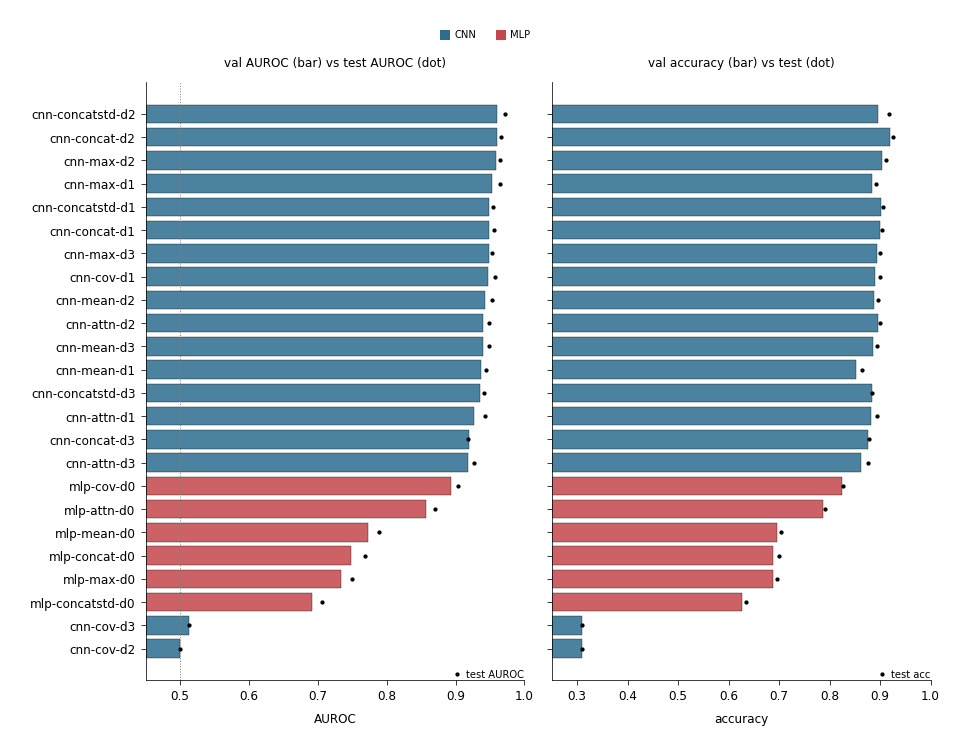

In [3]:
def plot_bars(df):
    d = df.iloc[::-1]                                     # best at top of a barh
    y = np.arange(len(d))
    colors = [ARCH_C[a] for a in d["arch"]]
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 0.34 * len(d) + 1.5), sharey=True)

    axA.barh(y, d["val_auroc"], color=colors, alpha=0.85, edgecolor="k", linewidth=0.4)
    axA.scatter(d["test_auroc"], y, color="k", s=18, zorder=3, label="test AUROC")
    axA.set_xlim(0.45, 1.0); axA.axvline(0.5, ls=":", color="gray", lw=1)
    axA.set_yticks(y); axA.set_yticklabels(d["label"])
    axA.set_xlabel("AUROC"); axA.set_title("val AUROC (bar) vs test AUROC (dot)")
    axA.legend(loc="lower right")

    axB.barh(y, d["val_acc"], color=colors, alpha=0.85, edgecolor="k", linewidth=0.4)
    axB.scatter(d["test_acc"], y, color="k", s=18, zorder=3, label="test acc")
    axB.set_xlim(0.25, 1.0); axB.set_xlabel("accuracy"); axB.set_title("val accuracy (bar) vs test (dot)")
    axB.legend(loc="lower right")

    handles = [Patch(facecolor=ARCH_C[a], edgecolor="k", label=a.upper()) for a in ("cnn", "mlp")]
    fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout(); plt.show()

plot_bars(df)

## Prediction machinery

Loads the compact `sub20k` cache once (into RAM) and scores any checkpoint's val/test split from it. The
scaffold label for each row comes from `sub20k_sequences.csv`, so we can slice metrics per ortholog later.
Predictions are cached in RAM per (checkpoint, split).

In [4]:
_D = {}
def get_data():
    """(D, scaffold_array): the sub20k cache + a global-row scaffold label array."""
    if "D" not in _D:
        _D["D"] = sw.load_data(dev)                       # H in RAM (~12 GB), plus tr/va/te idx + labels
        _D["scaf"] = pd.read_csv(sw.CSV)["scaffold"].values
    return _D["D"], _D["scaf"]

_PRED = {}
def get_pred(ckpt_file, split):
    """Return (prob, y, scaf, idx) for split in {'va','te'} from a classifier checkpoint."""
    key = (ckpt_file, split)
    if key not in _PRED:
        D, scaf = get_data()
        base, _ = pm.load_model(os.path.join(SWEEP_DIR, ckpt_file), dev, out=1)
        logits, idx = sw.predict_logits(base, D, D[split], dev)     # idx returned sorted
        prob = 1.0 / (1.0 + np.exp(-logits.astype(np.float64)))
        _PRED[key] = (prob, D["y"][idx].astype(int), scaf[idx], idx)
    return _PRED[key]

def val_opt_threshold(ckpt_file):
    """Decision threshold that maximizes F1 on the validation split."""
    pv, yv, _, _ = get_pred(ckpt_file, "va")
    grid = np.linspace(pv.min(), pv.max(), 200)
    return float(grid[int(np.argmax([f1_score(yv, (pv >= t).astype(int), zero_division=0) for t in grid]))])

print("prediction helpers ready")

prediction helpers ready


## ROC & precision–recall curves (top configs)

Threshold-free view on the held-out **test** split for the top-ranked configs. The dashed line is the random
baseline (ROC diagonal; PR at the positive/bright prevalence).

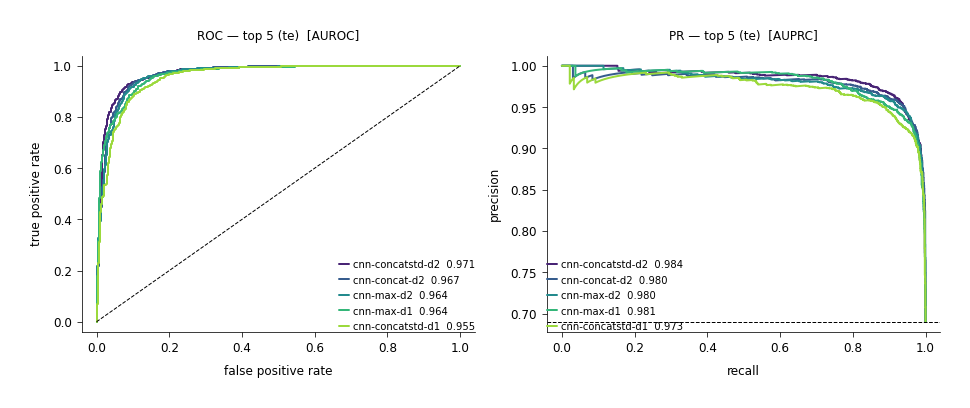

In [5]:
def plot_curves(df, k=5, split="te"):
    top = df.head(k)
    fig, (axR, axP) = plt.subplots(1, 2, figsize=(13, 5.2))
    cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(top)))
    prev = None
    for c, (_, r) in zip(cmap, top.iterrows()):
        prob, y, _, _ = get_pred(r["file"], split)
        prev = y.mean() if prev is None else prev
        fpr, tpr, _ = roc_curve(y, prob)
        axR.plot(fpr, tpr, color=c, lw=2, label=f"{r['label']}  {roc_auc_score(y, prob):.3f}")
        pr, rc, _ = precision_recall_curve(y, prob)
        axP.plot(rc, pr, color=c, lw=2, label=f"{r['label']}  {average_precision_score(y, prob):.3f}")
    axR.plot([0, 1], [0, 1], "k--", lw=1)
    axR.set_xlabel("false positive rate"); axR.set_ylabel("true positive rate")
    axR.set_title(f"ROC — top {k} ({split})  [AUROC]"); axR.legend(loc="lower right")
    axP.axhline(prev, ls="--", color="k", lw=1)
    axP.set_xlabel("recall"); axP.set_ylabel("precision")
    axP.set_title(f"PR — top {k} ({split})  [AUPRC]"); axP.legend(loc="lower left")
    plt.tight_layout(); plt.show()

plot_curves(df, k=5, split="te")

## Confusion matrix — best config

For the top-ranked config, pick the decision threshold that maximizes F1 on **val**, then report the **test**
confusion matrix and metrics at that threshold.

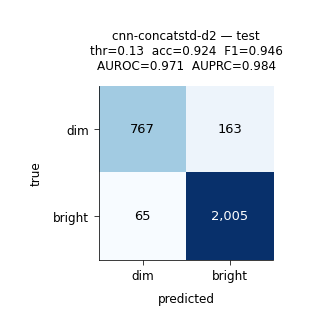

decision threshold (val-opt F1): 0.126


In [6]:
def confusion_report(df, rank=0):
    r = df.iloc[rank]
    thr = val_opt_threshold(r["file"])
    prob, y, _, _ = get_pred(r["file"], "te")
    yhat = (prob >= thr).astype(int)
    cm = confusion_matrix(y, yhat)                       # rows=true [dim,bright], cols=pred
    auroc = roc_auc_score(y, prob); auprc = average_precision_score(y, prob)
    f1 = f1_score(y, yhat); acc = (yhat == y).mean()

    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["dim", "bright"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["dim", "bright"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{r['label']} — test\nthr={thr:.2f}  acc={acc:.3f}  F1={f1:.3f}\nAUROC={auroc:.3f}  AUPRC={auprc:.3f}")
    plt.tight_layout(); plt.show()
    print(f"decision threshold (val-opt F1): {thr:.3f}")

confusion_report(df, rank=0)

## Per-scaffold generalization

Does the best model work across all four orthologs, or is the aggregate score carried by the easy ones? Test
AUROC and accuracy (at the val-opt threshold) broken out per scaffold. Each scaffold contributes ~750 test rows;
`bright%` is that scaffold's class balance, so accuracy should be read against it.

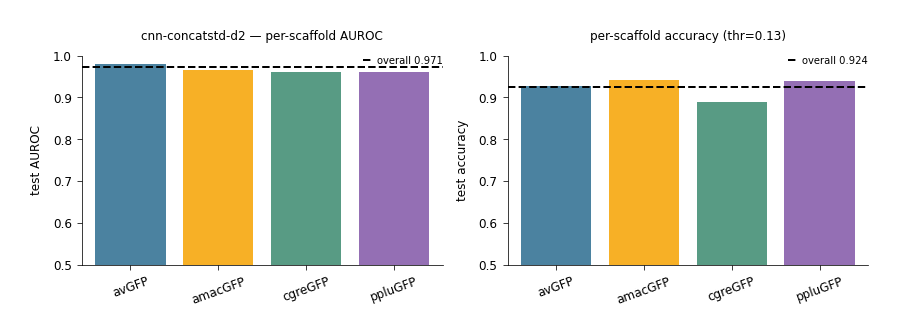

,scaffold,n,bright_pct,auroc,acc
0,avGFP,750,58.0,0.9807,0.9267
1,amacGFP,750,84.4,0.9662,0.9413
2,cgreGFP,750,52.1,0.9599,0.8880
3,ppluGFP,750,81.5,0.9598,0.9400


In [7]:
def per_scaffold(df, rank=0):
    r = df.iloc[rank]
    thr = val_opt_threshold(r["file"])
    prob, y, scaf, _ = get_pred(r["file"], "te")
    order = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
    rows = []
    for s in order:
        m = scaf == s
        au = roc_auc_score(y[m], prob[m]) if 0 < y[m].sum() < m.sum() else np.nan
        acc = ((prob[m] >= thr).astype(int) == y[m]).mean()
        rows.append(dict(scaffold=s, n=int(m.sum()), bright_pct=100 * y[m].mean(), auroc=au, acc=acc))
    tab = pd.DataFrame(rows)
    allau = roc_auc_score(y, prob); allacc = ((prob >= thr).astype(int) == y).mean()

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
    x = np.arange(len(order)); c = [POOL_C["max"], POOL_C["concat"], POOL_C["attn"], POOL_C["cov"]]
    a1.bar(x, tab["auroc"], color=c, edgecolor="k", alpha=0.85); a1.axhline(allau, ls="--", color="k", label=f"overall {allau:.3f}")
    a1.set_ylim(0.5, 1.0); a1.set_xticks(x); a1.set_xticklabels(order, rotation=20)
    a1.set_ylabel("test AUROC"); a1.set_title(f"{r['label']} — per-scaffold AUROC"); a1.legend()
    a2.bar(x, tab["acc"], color=c, edgecolor="k", alpha=0.85); a2.axhline(allacc, ls="--", color="k", label=f"overall {allacc:.3f}")
    a2.set_ylim(0.5, 1.0); a2.set_xticks(x); a2.set_xticklabels(order, rotation=20)
    a2.set_ylabel("test accuracy"); a2.set_title(f"per-scaffold accuracy (thr={thr:.2f})"); a2.legend()
    plt.tight_layout(); plt.show()
    return tab.style.format({"bright_pct": "{:.1f}", "auroc": "{:.4f}", "acc": "{:.4f}"})

per_scaffold(df, rank=0)

## Collapsed configs & summary

Configs whose training degenerated (val AUROC ≈ 0.5 — the classifier collapsed to one class). These are
excluded from any "best model" selection.

In [8]:
collapsed = df[df["val_auroc"] < COLLAPSE]
healthy   = df[df["val_auroc"] >= COLLAPSE]
print(f"collapsed ({len(collapsed)}): " + (", ".join(collapsed["label"]) if len(collapsed) else "none"))
print()

best = df.iloc[0]
by_arch = healthy.groupby("arch")["val_auroc"].agg(["mean", "max"])
print("val AUROC by backbone (healthy configs):")
print(by_arch.round(4).to_string())
print()
print(f"best overall : {best['label']}")
print(f"  val  AUROC {best['val_auroc']:.4f}  AUPRC {best['val_auprc']:.4f}  acc {best['val_acc']:.3f}  F1 {best['val_f1']:.3f}")
print(f"  test AUROC {best['test_auroc']:.4f}  AUPRC {best['test_auprc']:.4f}  acc {best['test_acc']:.3f}  F1 {best['test_f1']:.3f}")

collapsed (2): cnn-cov-d3, cnn-cov-d2

val AUROC by backbone (healthy configs):
        mean     max
arch                
cnn   0.9429  0.9609
mlp   0.7829  0.8932

best overall : cnn-concatstd-d2
  val  AUROC 0.9609  AUPRC 0.9787  acc 0.896  F1 0.922
  test AUROC 0.9714  AUPRC 0.9845  acc 0.917  F1 0.938


# Scaled-up model — `cnn-max-d2` trained on 40k (10k/scaffold, BS=128)

The sweep above used the 20k subsample (5k/scaffold). Here we evaluate the same top architecture retrained on
the **40k** subsample (`sub40k`, 10k/scaffold, batch size 128, 50-epoch cap) — checkpoint
`trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt`. This is a strict data-scaling check on the held-out split,
with a **per-scaffold, per-class (bright/dim)** breakdown to see where the extra data helps.

In [9]:
# Load the 40k model + its sub40k cache, score val/test, compare to the 20k cnn-max-d2.
FORTY_CKPT = "trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt"
d40 = sw.load_data(dev, stem="sub40k")                      # (~24 GB fp16 into RAM)
scaf40 = pd.read_csv(sw.data_paths("sub40k")[2])["scaffold"].values
net40, ck40 = pm.load_model(FORTY_CKPT, dev, out=1)

def pred40(split):
    logits, idx = sw.predict_logits(net40, d40, d40[split], dev)
    prob = 1.0 / (1.0 + np.exp(-logits.astype(np.float64)))
    return prob, d40["y"][idx].astype(int), scaf40[idx]

pv40, yv40, _ = pred40("va")
grid = np.linspace(pv40.min(), pv40.max(), 200)
THR40 = float(grid[int(np.argmax([f1_score(yv40, (pv40 >= t).astype(int), zero_division=0) for t in grid]))])
pt40, yt40, st40 = pred40("te")

def _metrics(y, p, thr):
    yhat = (p >= thr).astype(int)
    return dict(auroc=roc_auc_score(y, p), auprc=average_precision_score(y, p),
                acc=(yhat == y).mean(), f1=f1_score(y, yhat, zero_division=0))
mv, mt = _metrics(yv40, pv40, THR40), _metrics(yt40, pt40, THR40)
print(f"cnn-max-d2 @ 40k  (n_train={ck40.get('n_train')}, best@ep{ck40.get('epoch_best')}, val-opt thr={THR40:.3f})")
print(f"  val : AUROC {mv['auroc']:.4f}  AUPRC {mv['auprc']:.4f}  acc {mv['acc']:.3f}  F1 {mv['f1']:.3f}")
print(f"  test: AUROC {mt['auroc']:.4f}  AUPRC {mt['auprc']:.4f}  acc {mt['acc']:.3f}  F1 {mt['f1']:.3f}")

prev = df[df.label == "cnn-max-d2"].iloc[0]                 # the 20k sweep entry
print(f"\n  data scaling 20k -> 40k (cnn-max-d2):")
print(f"    test AUROC {float(prev['test_auroc']):.4f} -> {mt['auroc']:.4f}  ({mt['auroc']-float(prev['test_auroc']):+.4f})")
print(f"    test acc   {float(prev['test_acc']):.3f} -> {mt['acc']:.3f}  ({mt['acc']-float(prev['test_acc']):+.3f})")

cnn-max-d2 @ 40k  (n_train=28000, best@ep34, val-opt thr=0.327)
  val : AUROC 0.9816  AUPRC 0.9917  acc 0.948  F1 0.963
  test: AUROC 0.9809  AUPRC 0.9911  acc 0.943  F1 0.959

  data scaling 20k -> 40k (cnn-max-d2):
    test AUROC 0.9643 -> 0.9809  (+0.0166)
    test acc   0.911 -> 0.943  (+0.032)


## Per-scaffold, per-class performance (40k model)

Test-split metrics for each ortholog, split by class. `bright_recall` / `dim_recall` are the per-class
detection rates at the val-optimized threshold; `bright%` is that scaffold's class balance. The minority
(dim) class on the bright-skewed scaffolds (amacGFP, ppluGFP) is the hardest case, so watch `dim_recall` there.

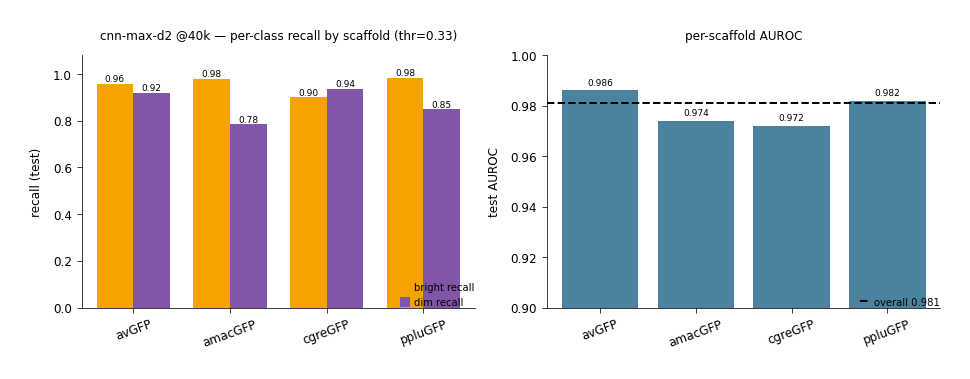

,scaffold,n,bright_pct,AUROC,acc,bright_recall,dim_recall,bright_prec,dim_prec
0,avGFP,1500,60.0,0.9862,0.9433,0.959,0.920,0.947,0.937
1,amacGFP,1500,84.2,0.9741,0.9487,0.979,0.785,0.960,0.877
2,cgreGFP,1500,51.1,0.9721,0.9180,0.901,0.936,0.936,0.900
3,ppluGFP,1500,83.7,0.9820,0.9627,0.985,0.848,0.971,0.916
4,ALL,6000,69.8,0.9809,0.9432,0.962,0.899,0.957,0.912


In [10]:
def per_scaffold_class(prob, y, scaf, thr):
    order = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP", "ALL"]
    rows = []
    for s in order:
        m = np.ones(len(y), bool) if s == "ALL" else (scaf == s)
        yy, pp = y[m], prob[m]; yhat = (pp >= thr).astype(int)
        au = roc_auc_score(yy, pp) if 0 < yy.sum() < len(yy) else np.nan
        rows.append(dict(scaffold=s, n=int(m.sum()), bright_pct=100 * yy.mean(), AUROC=au,
                         acc=(yhat == yy).mean(),
                         bright_recall=((yhat == 1) & (yy == 1)).sum() / max((yy == 1).sum(), 1),
                         dim_recall=((yhat == 0) & (yy == 0)).sum() / max((yy == 0).sum(), 1),
                         bright_prec=((yhat == 1) & (yy == 1)).sum() / max((yhat == 1).sum(), 1),
                         dim_prec=((yhat == 0) & (yy == 0)).sum() / max((yhat == 0).sum(), 1)))
    return pd.DataFrame(rows)

tab40 = per_scaffold_class(pt40, yt40, st40, THR40)
sc = tab40[tab40.scaffold != "ALL"]; allrow = tab40[tab40.scaffold == "ALL"].iloc[0]
x = np.arange(len(sc)); w = 0.38

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
a1.bar(x - w / 2, sc.bright_recall, w, label="bright recall", color="#f6a200", edgecolor="k")
a1.bar(x + w / 2, sc.dim_recall,    w, label="dim recall",    color="#8156a7", edgecolor="k")
for i, (b, d) in enumerate(zip(sc.bright_recall, sc.dim_recall)):
    a1.text(i - w / 2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    a1.text(i + w / 2, d + 0.01, f"{d:.2f}", ha="center", fontsize=9)
a1.set_xticks(x); a1.set_xticklabels(sc.scaffold, rotation=20); a1.set_ylim(0, 1.08)
a1.set_ylabel("recall (test)"); a1.set_title(f"cnn-max-d2 @40k — per-class recall by scaffold (thr={THR40:.2f})")
a1.legend(loc="lower right")

a2.bar(x, sc.AUROC, color="#2b6c8f", edgecolor="k", alpha=0.85)
a2.axhline(allrow.AUROC, ls="--", color="k", label=f"overall {allrow.AUROC:.3f}")
for i, v in enumerate(sc.AUROC):
    a2.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
a2.set_xticks(x); a2.set_xticklabels(sc.scaffold, rotation=20); a2.set_ylim(0.9, 1.0)
a2.set_ylabel("test AUROC"); a2.set_title("per-scaffold AUROC"); a2.legend(loc="lower right")
plt.tight_layout(); plt.show()

tab40.style.format({"bright_pct": "{:.1f}", "AUROC": "{:.4f}", "acc": "{:.4f}", "bright_recall": "{:.3f}",
                    "dim_recall": "{:.3f}", "bright_prec": "{:.3f}", "dim_prec": "{:.3f}"}) \
     .set_caption("cnn-max-d2 @ 40k — per-scaffold, per-class (test)")